# 039 损失设计失衡与校准

先运行完整性检查，再沿完整手算、独立测试、九次训练、验证后处理、分组评价的顺序执行。训练使用CPU float64。所有数据为原创合成；本Notebook不下载数据、不读取远端账户，也不覆盖参考输出。

In [1]:
from pathlib import Path
import os, sys, hashlib
candidates = []
if os.environ.get('UNIT039_DIR'):
    candidates.append(Path(os.environ['UNIT039_DIR']).expanduser())
candidates += [Path.cwd(), Path.cwd() / 'units' / '039', Path.cwd() / 'dl-course-production' / 'units' / '039']
unit = next((p.resolve() for p in candidates if (p / 'experiment.py').is_file() and (p / 'data' / 'train.csv').is_file()), None)
if unit is None:
    raise RuntimeError('找不到039单元。请从单元目录运行，或设置UNIT039_DIR。')
expected = {'experiment.py': '8f01f646a6253ec656c0b019671e49175251b81a3252dd63ce9089d9ded93c35', 'test_experiment.py': '9d92ca9d168c95c452f20c016482abde3ef444b174115543ed7a58b47ae40fb1', 'make_figures.py': '85d9bf958b72a0f4c3a482c460bebe733f334eeb4133fe534258e6236cc03753', 'data/test.csv': '592b6c7814a48628fcd2afd8d68f628bd672ec9cf47d4c18c3bdf1c522b326b8', 'data/train.csv': '87f4b73ac0af0229f805671b29962fbd211d2aac0a7bac127a8c96eb14e4700b', 'data/validation.csv': 'a77b069b71dc5c61805978023ea079946c553a36841d3dc7c0f765b3cbf7df71', 'outputs/calculations.json': '37b43f04a5ac1b8ee4745555869ec9504a1a05db6e88e81e372fe5ba2fe82031', 'outputs/frozen-plan.json': '761572bcba6f60ce6dc68f1ac20369abc7914b22b8ecde8667d624e9130260ba', 'outputs/metrics.csv': '13d1136de69dcd85047664aab312d0421e77e39bf760ae70244f8b0cb45b7d58', 'outputs/predictions.csv': 'aa976dd17d7b8f884c469902e655cfd011b4159009d5b81b51b0cae63917844d', 'outputs/reliability.csv': '96a8772c925931c06454faecb8ea9b7ae8ea711bd9c2fa259d7607b5d3e6f8c3', 'outputs/training-history.csv': 'c993f00d4ab74d127f55462d6cbfd8c0f431ead9693ab60208dd12e0553f2c4a', 'outputs/validation-cost-curves.csv': 'f083125cbca276a12c2c59c8226b646ea79d77a11f84b9593dd4f7579247efc8', 'figures/01_three_objects.png': 'f6c5f070ebf349b4d2a1ed5490c163033e7e1832a583ca9d3ba5deabf45f401c', 'figures/02_weighted_posterior.png': '550cf0dc580f6539e68a54a4fb5967e1045326f5fd50f27a0ee1d1a941d41d6a', 'figures/03_denominators_sampling.png': 'b85232f443fb5c727af0e42ff55253737bcac0b95780a62cb7860aa4cedf1c8c', 'figures/04_complete_gradient_paths.png': '848e590b111fbe38b714040b31a564e8013edaeb830179531c7fc2e9969e4070', 'figures/05_cost_threshold.png': 'cc6a20c3a07112badfe925942c4c785f8e85efb488d0d3b8f76738df42ba5c1d', 'figures/06_shift_vs_temperature.png': '174073f43f8c325cb36abd81507e08179fb9d3cad233aea7d6f4efcdc3bd0cfb', 'figures/07_temperature_fit.png': 'bb238a7475add4eb7dbddaa3dfceb0d33647659caa10a608af675d4e930291c1', 'figures/08_actual_probability_metrics.png': 'de8df6f59a6a0073c92a7ebe03e2a0e1f08adbea459a747ef2e126c8f45cdc8f', 'figures/09_reliability_curves.png': '6fae3f148c0504e706f7b6c8b65b45f00621c28fb35cdc5fbfe77a91f52d5469', 'figures/10_decision_cost_curves.png': 'a608a06f0c314142b152a70367b436ad8e01ec8d520591a3fe55f0bfb23c8f7d', 'figures/11_groups_and_bins.png': '08d19cd8a47a37a8892dbd5d89c3656c97788b833b7f665dde60c34d81037c41', 'figures/12_decision_surfaces.png': '1f2b0181a538378746acba200afdc262bd099891d76f77cab0fbdf9666068be4', 'figures/13_decision_surfaces.png': '1889ca62940f6f24eeb157be02e2b3f1f536a0fa82ccde3b6a4bf0b66ba1fa35', 'figures/14_bin_cancellation.png': '9133f33ccea2abf5c66813676d3bcba8b0a855d3cabc937741f1a0c4812e3b8c'}
for relative, digest in expected.items():
    path = unit / relative
    if not path.is_file() or hashlib.sha256(path.read_bytes()).hexdigest() != digest:
        raise RuntimeError('完整性检查失败：' + relative + '；请使用同一版本代码、数据、结果和图。')
sys.path.insert(0, str(unit))
print('完整性检查通过：', len(expected), '份代码、数据、参考输出与图；尚未导入实验模块。')


完整性检查通过： 27 份代码、数据、参考输出与图；尚未导入实验模块。


## 1 环境与教学范围
实际版本与代码独立打印。环境差异可能影响位级结果；不能删去核验后宣称复现同一版本。

In [2]:
import json, csv, tempfile, io, unittest, platform
import numpy as np
import torch
import experiment as e
print({'python': platform.python_version(), 'numpy': np.__version__, 'torch': torch.__version__, 'device': 'cpu', 'dtype': 'float64'})
print('九个训练过程，固定240轮；温度与阈值各使用独立200条验证记录。')


{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'cpu', 'dtype': 'float64'}
九个训练过程，固定240轮；温度与阈值各使用独立200条验证记录。


## 2 完整九参数手算
first保存逐样本前向、局部导数、路径梯度、同步更新；next用更新后参数从头计算。所有显示的数值直接来自代码，不从旧输出复制。

In [3]:
first = e.hand_trace()
second = e.hand_trace(first['theta_next'])
for name, trace in [('first', first), ('next', second)]:
    print(name)
    print(json.dumps(trace, ensure_ascii=False, indent=2))
print('加权总风险下降，但第二条样本的BCE上升：', first['risk'], second['risk'], first['losses'][1], second['losses'][1])


first
{
  "theta": [
    0.5,
    -0.2,
    0.3,
    0.4,
    0.1,
    0.2,
    0.6,
    -0.5,
    0.1
  ],
  "x": [
    [
      1.0,
      2.0
    ],
    [
      -1.0,
      1.0
    ]
  ],
  "y": [
    1.0,
    0.0
  ],
  "weights": [
    3.0,
    1.0
  ],
  "denominator": 4,
  "preactivation": [
    [
      1.2000000000000002,
      0.8
    ],
    [
      -0.1,
      0.8
    ]
  ],
  "hidden": [
    [
      1.2000000000000002,
      0.8
    ],
    [
      0.0,
      0.8
    ]
  ],
  "logits": [
    0.42000000000000004,
    -0.30000000000000004
  ],
  "probabilities": [
    0.6034832498647262,
    0.42555748318834097
  ],
  "losses": [
    0.5050369938177537,
    0.5543552444685271
  ],
  "weighted_contributions": [
    0.37877774536331527,
    0.13858881111713178
  ],
  "risk": 0.517366556480447,
  "local_dloss_dp": [
    -1.657046819815057,
    1.7408182206817178
  ],
  "local_dp_ds": [
    0.23929121699743464,
    0.24445831169074586
  ],
  "dlogits": [
    -0.2973875626014553,
   

## 3 两个归约分母与重采样期望
固定样本损失时，加权平均和按权重抽样的期望相同。随机批内分母不是固定总体分母。先手算，再核对程序。

In [4]:
by_count = e.weighted_risk(first['logits'], first['y'], first['weights'], 'count')
by_weights = e.weighted_risk(first['logits'], first['y'], first['weights'], 'weights')
print({'count_mean': by_count, 'weight_mean': by_weights, 'ratio': by_count/by_weights})
losses = np.array([.1, .6, 1.3]); weights = np.array([1., 2., 3.]); q = weights/weights.sum()
expectation = sum(q[i]*q[j]*(losses[i]+losses[j])/2 for i in range(3) for j in range(3))
print('两次抽样9种有序结果精确枚举期望：', expectation)
print('批大小1时自归一化均匀估计的期望：', losses.mean())


{'count_mean': 1.034733112960894, 'weight_mean': 0.517366556480447, 'ratio': 2.0}
两次抽样9种有序结果精确枚举期望： 0.8666666666666667
批大小1时自归一化均匀估计的期望： 0.6666666666666666


## 4 独立数值参考与输入失败测试
测试并非只比较同一个函数的两次调用：Decimal标量参考、手写NumPy的2160次更新、全部162行指标的独立标量重算、黄金分割温度最小化，分别交叉检查生产实现。

In [5]:
import test_experiment as tests
suite = unittest.defaultTestLoader.loadTestsFromTestCase(tests.Test039)
report = io.StringIO()
test_result = unittest.TextTestRunner(stream=report, verbosity=1).run(suite)
print(report.getvalue())
if not test_result.wasSuccessful():
    raise RuntimeError('独立测试未通过')
print(tests.ERRORS)


................
----------------------------------------------------------------------
Ran 16 tests in 1.560s

OK

{'training_final_parameter_max': 2.220446049250313e-16, 'training_loss_max': 3.3306690738754696e-16, 'hand_finite_difference_max': 4.187752922213406e-11, 'temperature_golden_beta_max': 3.108548396468791e-08}


## 5 从头训练全部九次并核对七份输出
临时目录会在比较后清理。参考outputs不会被覆盖。这里不使用缓存模型，2160次SGD更新全部重跑。

In [6]:
with tempfile.TemporaryDirectory(prefix='unit039-run-') as temporary:
    result = e.run(output=Path(temporary))
    for filename, digest in result['sha256'].items():
        if digest != expected['outputs/' + filename]:
            raise RuntimeError('重跑结果不一致：' + filename)
    print({k:v for k,v in result.items() if k != 'sha256'})
    print('七份结果SHA-256与冻结参考逐个一致。')


{'protocol': '039-v1', 'epochs': 240, 'runs': 9, 'updates': 2160, 'presentations': 518400, 'test_prediction_rows': 54000, 'metric_rows': 162, 'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.7.1+cpu', 'device': 'cpu', 'dtype': 'float64'}
七份结果SHA-256与冻结参考逐个一致。


## 6 只用验证数据选择的温度与阈值
温度作用在先验修正后的logits上；直接对原始logits做温度的失败对照另存。当前九个经验阈值都为.2，是本次数据的观察。

In [7]:
plan = json.loads((unit/'outputs/frozen-plan.json').read_text())
for run in plan['runs']:
    print(run['method'], run['seed'], 'T=', round(run['temperature']['temperature'], 8), 'raw_T=', round(run['temperature_without_prior']['temperature'], 8), 'threshold=', run['threshold'], 'status=', run['temperature']['status'])
print('π_train=', plan['train_prevalence'], 'theoretical threshold=', e.FP_COST/(e.FP_COST+e.FN_COST))


uniform 11 T= 1.05121605 raw_T= 1.05121605 threshold= 0.2 status= interior
uniform 23 T= 1.07873134 raw_T= 1.07873134 threshold= 0.2 status= interior
uniform 37 T= 1.07738577 raw_T= 1.07738577 threshold= 0.2 status= interior
weighted 11 T= 1.13345173 raw_T= 1.2267418 threshold= 0.2 status= interior
weighted 23 T= 1.15174994 raw_T= 1.24585131 threshold= 0.2 status= interior
weighted 37 T= 1.14273199 raw_T= 1.23167232 threshold= 0.2 status= interior
resampled 11 T= 1.12951759 raw_T= 1.19887353 threshold= 0.2 status= interior
resampled 23 T= 1.12620475 raw_T= 1.2319001 threshold= 0.2 status= interior
resampled 37 T= 1.16891669 raw_T= 1.26895085 threshold= 0.2 status= interior
π_train= 0.30833333333333335 theoretical threshold= 0.2


## 7 阈值不会改变NLL/Brier/ECE
逐一比较同一网络、同一组的prior_temperature与cost_validation。只换行动，概率质量指标应保持。

In [8]:
rows = list(csv.DictReader((unit/'outputs/metrics.csv').read_text().splitlines()))
index = {(r['method'],r['seed'],r['view'],r['group']):r for r in rows}
checked = 0
for run in plan['runs']:
    for group in ['all','0','1']:
        a=index[(run['method'],str(run['seed']),'prior_temperature',group)]
        b=index[(run['method'],str(run['seed']),'cost_validation',group)]
        for key in ['nll','brier','ece','ece5','ece20']:
            if a[key] != b[key]: raise RuntimeError('概率指标意外改变：'+key)
        checked += 1
print('不变量检查组合数：', checked)


不变量检查组合数： 27


## 8 分组评价必须带支持数
下面保留seed=11的全部分组，既有准确率，也有概率评分与代价。不要把样本数较小的组当作同等精确的估计。

In [9]:
for method in e.METHODS:
    for group in ['all','0','1']:
        r = index[(method,'11','prior_temperature',group)]
        print(method, 'group='+group, {k:r[k] for k in ['n','positive','accuracy','nll','brier','ece','cost']})


uniform group=all {'n': '1000', 'positive': '294', 'accuracy': '0.73', 'nll': '0.5285150629196196', 'brier': '0.17802473297943402', 'ece': '0.029766712315230343', 'cost': '0.789'}
uniform group=0 {'n': '731', 'positive': '190', 'accuracy': '0.7373461012311902', 'nll': '0.5088199921911235', 'brier': '0.17036448365327342', 'ece': '0.04824754838119608', 'cost': '0.7551299589603283'}
uniform group=1 {'n': '269', 'positive': '104', 'accuracy': '0.7100371747211895', 'nll': '0.5820358685052357', 'brier': '0.1988412469475507', 'ece': '0.07188424807331521', 'cost': '0.8810408921933085'}
weighted group=all {'n': '1000', 'positive': '294', 'accuracy': '0.726', 'nll': '0.5294015779677657', 'brier': '0.17857455153731688', 'ece': '0.03169872184584798', 'cost': '0.775'}
weighted group=0 {'n': '731', 'positive': '190', 'accuracy': '0.7318741450068399', 'nll': '0.5097145257884734', 'brier': '0.17096692206117972', 'ece': '0.052018386611171794', 'cost': '0.7400820793433652'}
weighted group=1 {'n': '269',

## 9 原创图与实际预测
图的原始字节已在首格核验。可靠性图的小点可能只有极少记录，必须结合reliability.csv理解。

07_temperature_fit.png


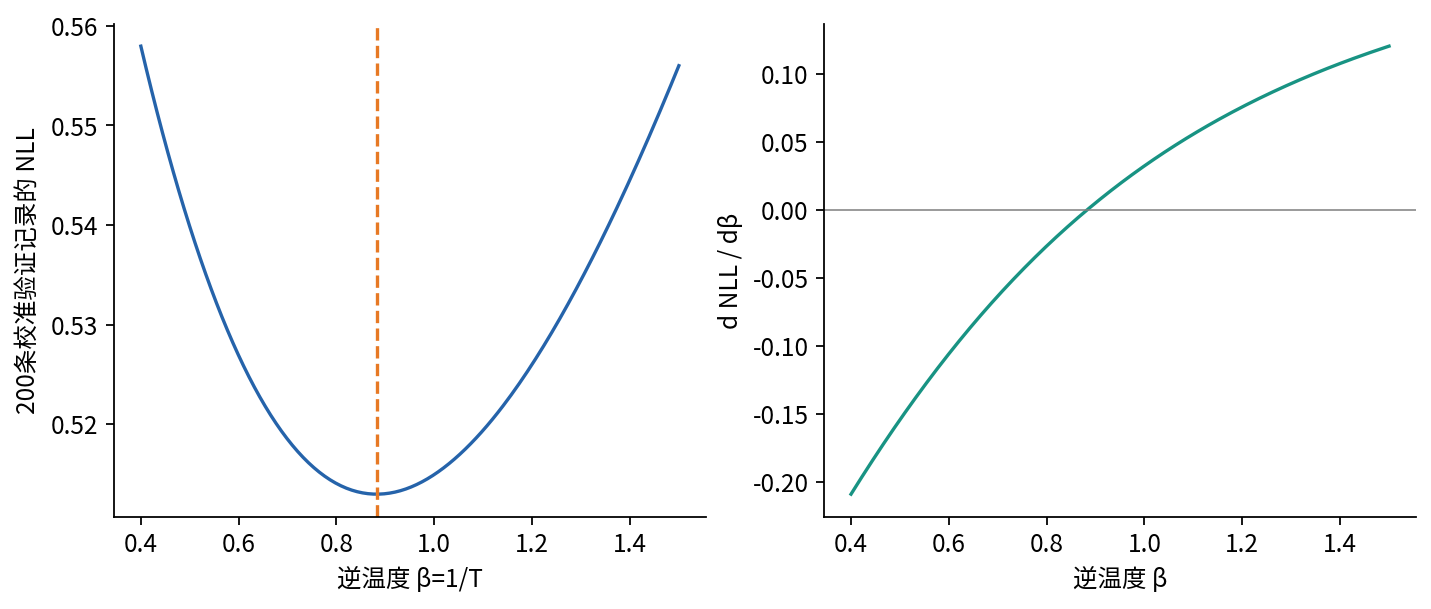

09_reliability_curves.png


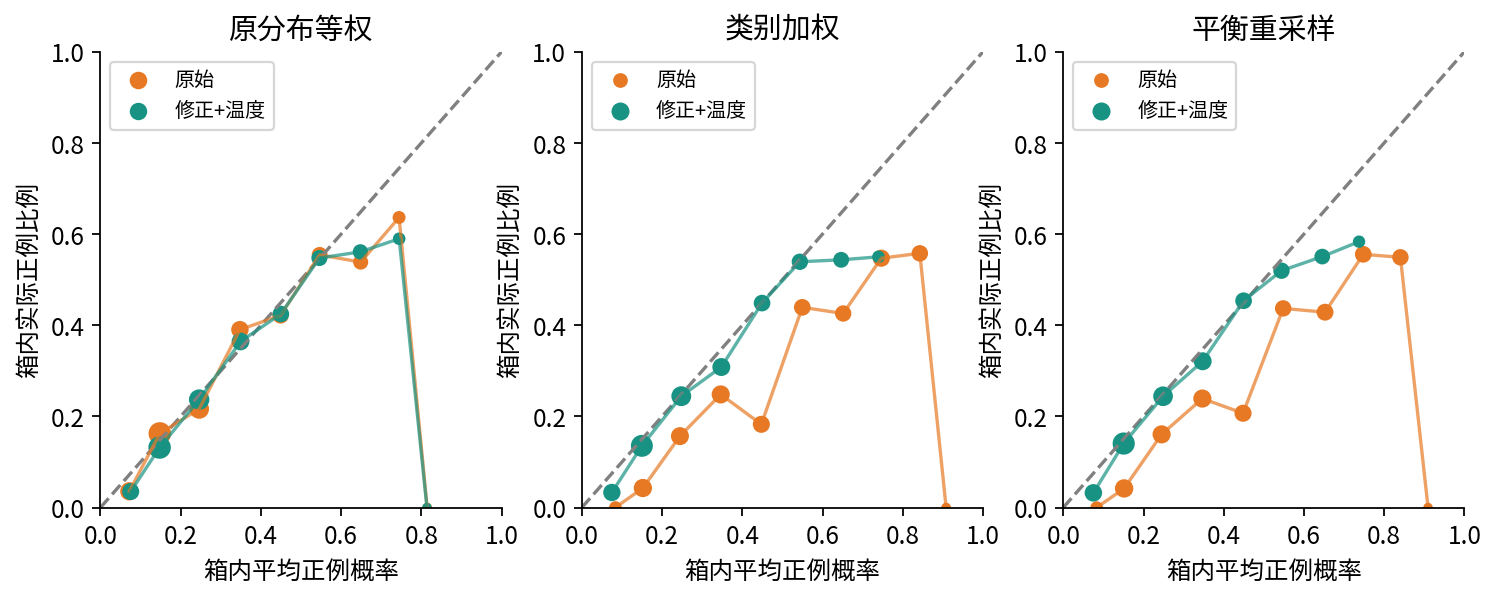

10_decision_cost_curves.png


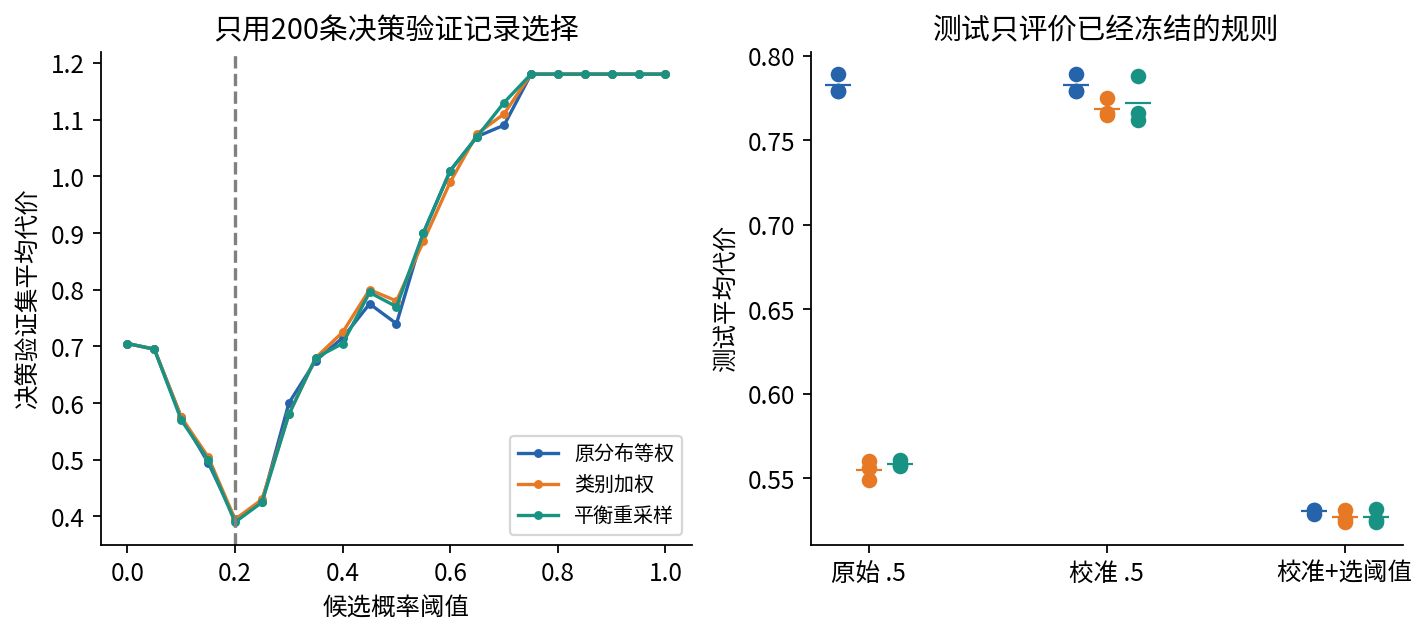

11_groups_and_bins.png


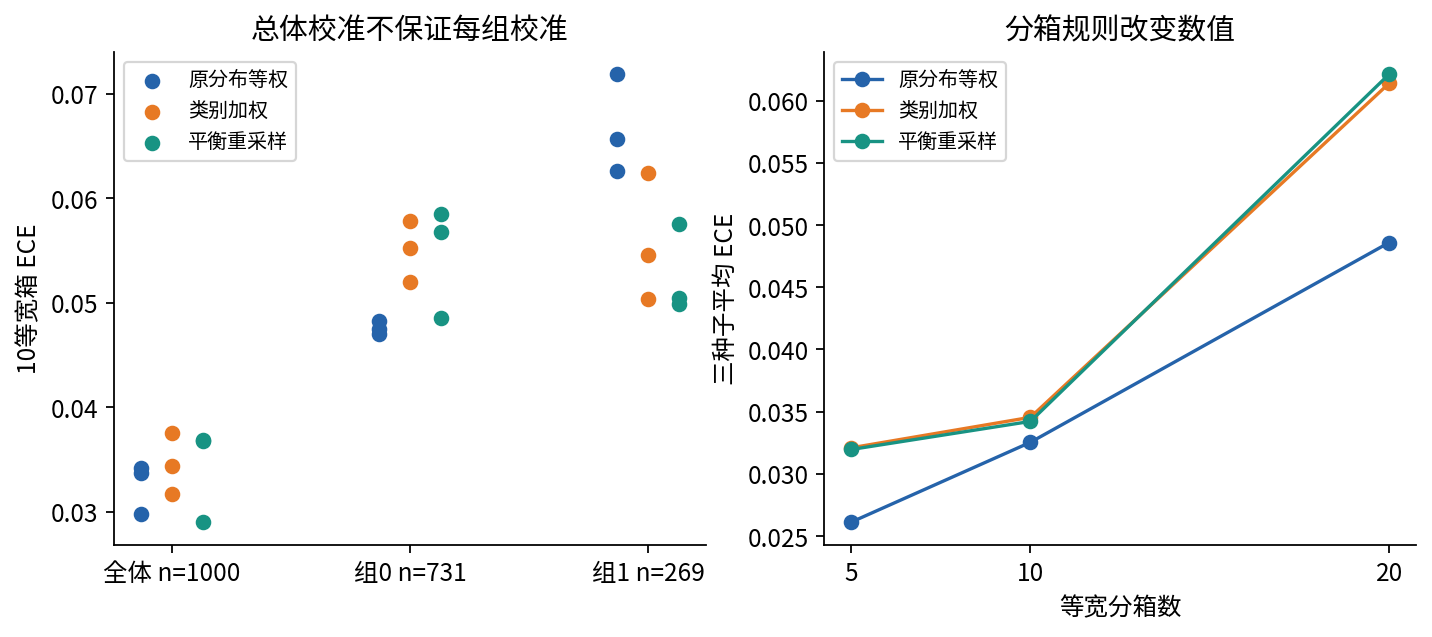

In [10]:
from IPython.display import display, Image
for filename in ['07_temperature_fit.png','09_reliability_curves.png','10_decision_cost_curves.png','11_groups_and_bins.png']:
    print(filename)
    display(Image(filename=str(unit/'figures'/filename), width=900))


## 10 ECE分箱抵消反例
模型和标签固定，只改变箱数。ECE=0并不等于获得了总体完美校准的证据。

In [11]:
probabilities=np.array([.1,.1,.9,.9]); logits=np.log(probabilities/(1-probabilities)); labels=[0,1,0,1]
for bins in [1,2,10]:
    m=e.metrics(logits,labels,bins=bins)
    print({'bins':bins,'ece':m['ece'],'nll':m['nll'],'brier':m['brier']})


{'bins': 1, 'ece': 0.0, 'nll': 1.203972804325936, 'brier': 0.41000000000000003}
{'bins': 2, 'ece': 0.4, 'nll': 1.203972804325936, 'brier': 0.41000000000000003}
{'bins': 10, 'ece': 0.4, 'nll': 1.203972804325936, 'brier': 0.41000000000000003}


## 11 正温度的边界与研究下一步
全零logits无法识别温度；可分数据可把有限区间最优推到边界。下一步研究应另留测试数据，不用本Notebook已经展示的测试继续选择。

In [12]:
for logits, labels in [([0.,0.],[0,1]),([-1.,1.],[0,1]),([-1.,1.],[1,0])]:
    answer=e.fit_temperature(logits,labels)
    print({k:answer[k] for k in ['status','beta','temperature','nll_before','nll_after']})
print('完成：代码执行、独立数值核对和有限合成结果；没有GPU或真实任务有效性声明。')


{'status': 'flat', 'beta': 1.0, 'temperature': 1.0, 'nll_before': 0.6931471805599453, 'nll_after': 0.6931471805599453}
{'status': 'upper_bound', 'beta': 20.0, 'temperature': 0.05, 'nll_before': 0.31326168751822286, 'nll_after': 2.061153620314381e-09}
{'status': 'lower_bound', 'beta': 0.05, 'temperature': 20.0, 'nll_before': 1.3132616875182228, 'nll_after': 0.7184596480132863}
完成：代码执行、独立数值核对和有限合成结果；没有GPU或真实任务有效性声明。
